<a href="https://colab.research.google.com/github/krishnamohan15/Wine-Quality-Prediction-System/blob/main/Wine_Quality_Prediction_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = pd.read_csv('/content/WineQT.csv')

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [3]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


## 2. Basic Data Inspection

In [4]:
print("Shape of dataset:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

Shape of dataset:
(1143, 13)

Column names:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality', 'Id']

Data types:
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
Id                        int64
dtype: object


In [5]:
print("Number of unique values in each column:")
print(df.nunique())

Number of unique values in each column:
fixed acidity             91
volatile acidity         135
citric acid               77
residual sugar            80
chlorides                131
free sulfur dioxide       53
total sulfur dioxide     138
density                  388
pH                        87
sulphates                 89
alcohol                   61
quality                    6
Id                      1143
dtype: int64


In [6]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64


In [7]:
print("Number of duplicate rows:")
print(df.duplicated().sum())

Number of duplicate rows:
0


In [8]:
print("Wine Quality Distribution:")
print(df['quality'].value_counts().sort_index())

Wine Quality Distribution:
quality
3      6
4     33
5    483
6    462
7    143
8     16
Name: count, dtype: int64


In [9]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


## 3. Data Cleaning

In [10]:
df = df.drop('Id', axis=1)

print("Id column removed successfully!")
print(df.columns.tolist())

Id column removed successfully!
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']


## 4. Exploratory Data Analysis (EDA)

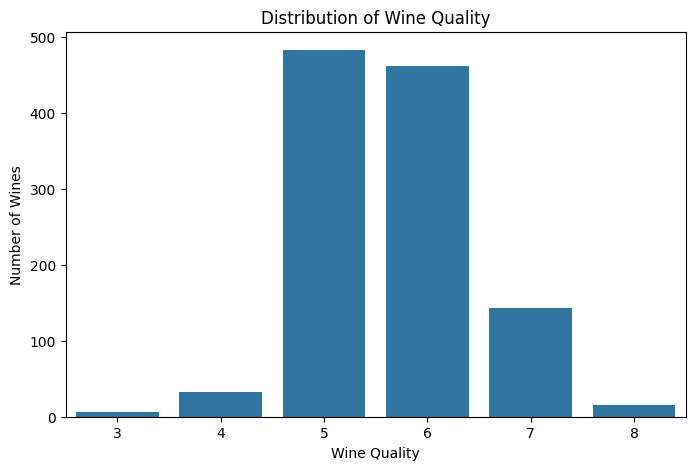

In [11]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x='quality')

plt.title('Distribution of Wine Quality')
plt.xlabel('Wine Quality')
plt.ylabel('Number of Wines')

plt.show()

In [12]:
quality_counts = df['quality'].value_counts().sort_index()

print("Quality distribution:")
print(quality_counts)

print("\nMost common quality:")
print(quality_counts.idxmax(),
      "with", quality_counts.max(), "wines")

print("\nLeast common quality:")
print(quality_counts.idxmin(),
      "with", quality_counts.min(), "wines")

Quality distribution:
quality
3      6
4     33
5    483
6    462
7    143
8     16
Name: count, dtype: int64

Most common quality:
5 with 483 wines

Least common quality:
3 with 6 wines


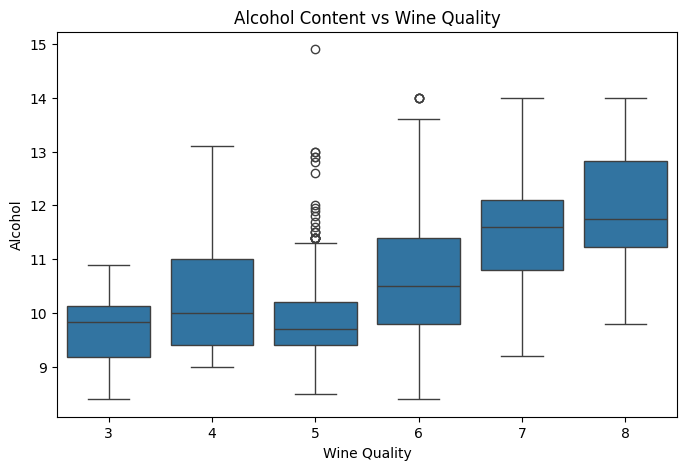

In [13]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x='quality', y='alcohol')

plt.title('Alcohol Content vs Wine Quality')
plt.xlabel('Wine Quality')
plt.ylabel('Alcohol')

plt.show()

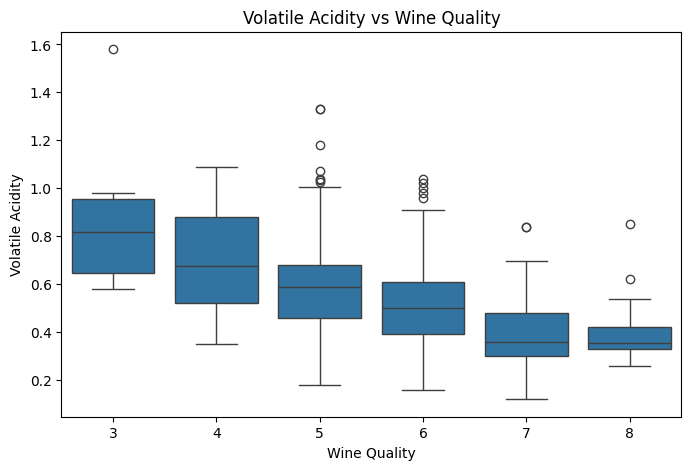

In [14]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x='quality', y='volatile acidity')

plt.title('Volatile Acidity vs Wine Quality')
plt.xlabel('Wine Quality')
plt.ylabel('Volatile Acidity')

plt.show()

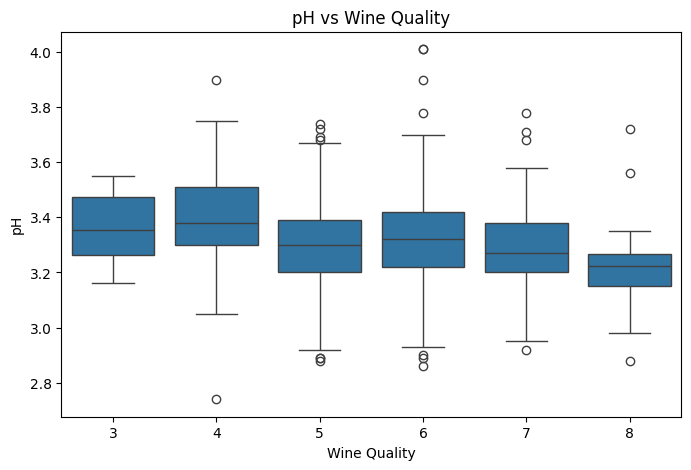

In [15]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x='quality', y='pH')

plt.title('pH vs Wine Quality')
plt.xlabel('Wine Quality')
plt.ylabel('pH')

plt.show()

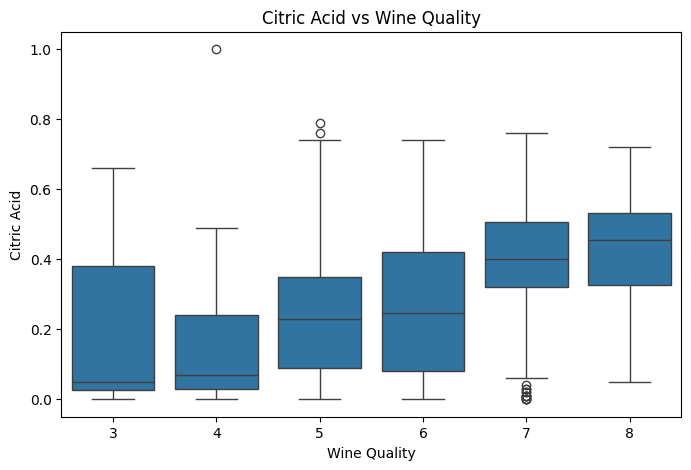

In [16]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x='quality', y='citric acid')

plt.title('Citric Acid vs Wine Quality')
plt.xlabel('Wine Quality')
plt.ylabel('Citric Acid')

plt.show()

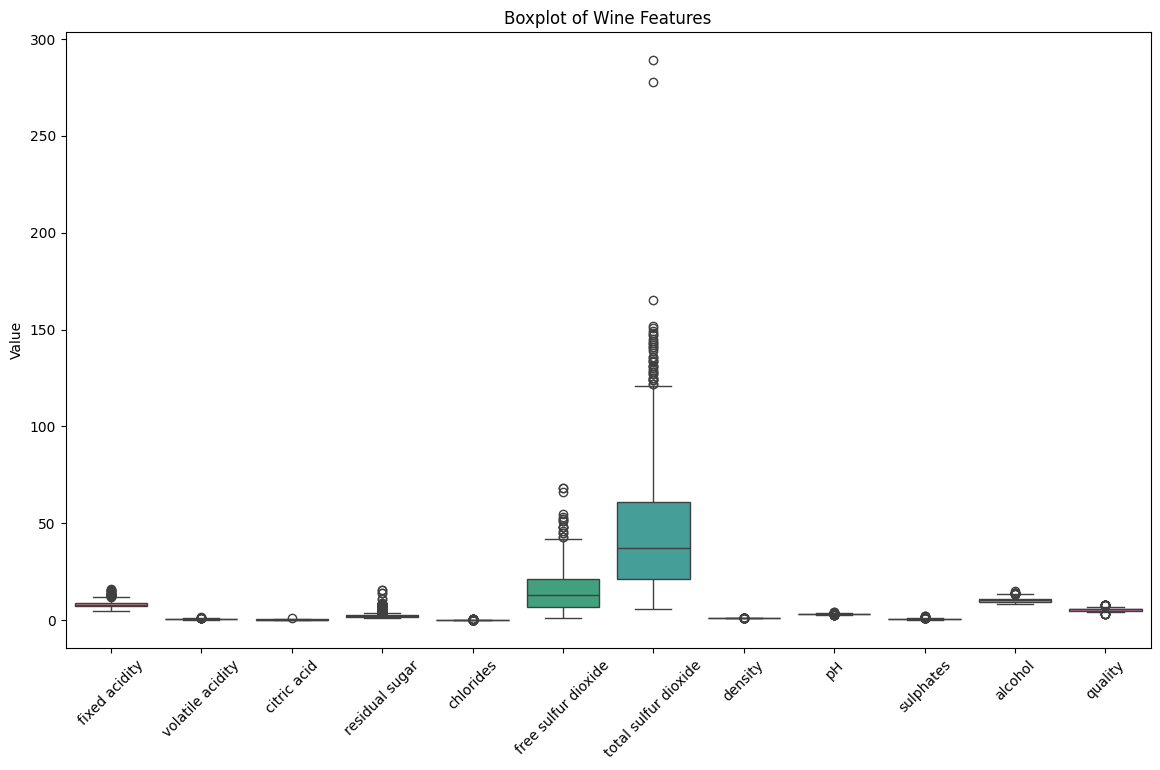

In [17]:
plt.figure(figsize=(14, 8))

sns.boxplot(data=df)

plt.title('Boxplot of Wine Features')
plt.xticks(rotation=45)
plt.ylabel('Value')

plt.show()

## 5. Correlation Analysis

In [18]:
correlation_matrix = df.corr()

print("Correlation Matrix:")
display(correlation_matrix)

Correlation Matrix:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
fixed acidity,1.000000,-0.250728,0.673157,0.171831,0.107889,-0.164831,-0.110628,0.681501,-0.685163,0.174592,-0.075055,0.121970
volatile acidity,-0.250728,1.000000,-0.544187,-0.005751,0.056336,-0.001962,0.077748,0.016512,0.221492,-0.276079,-0.203909,-0.407394
citric acid,0.673157,-0.544187,1.000000,0.175815,0.245312,-0.057589,0.036871,0.375243,-0.546339,0.331232,0.106250,0.240821
residual sugar,0.171831,-0.005751,0.175815,1.000000,0.070863,0.165339,0.190790,0.380147,-0.116959,0.017475,0.058421,0.022002
chlorides,0.107889,0.056336,0.245312,0.070863,1.000000,0.015280,0.048163,0.208901,-0.277759,0.374784,-0.229917,-0.124085
free sulfur dioxide,-0.164831,-0.001962,-0.057589,0.165339,0.015280,1.000000,0.661093,-0.054150,0.072804,0.034445,-0.047095,-0.063260
total sulfur dioxide,-0.110628,0.077748,0.036871,0.190790,0.048163,0.661093,1.000000,0.050175,-0.059126,0.026894,-0.188165,-0.183339
density,0.681501,0.016512,0.375243,0.380147,0.208901,-0.054150,0.050175,1.000000,-0.352775,0.143139,-0.494727,-0.175208
pH,-0.685163,0.221492,-0.546339,-0.116959,-0.277759,0.072804,-0.059126,-0.352775,1.000000,-0.185499,0.225322,-0.052453
sulphates,0.174592,-0.276079,0.331232,0.017475,0.374784,0.034445,0.026894,0.143139,-0.185499,1.000000,0.094421,0.257710


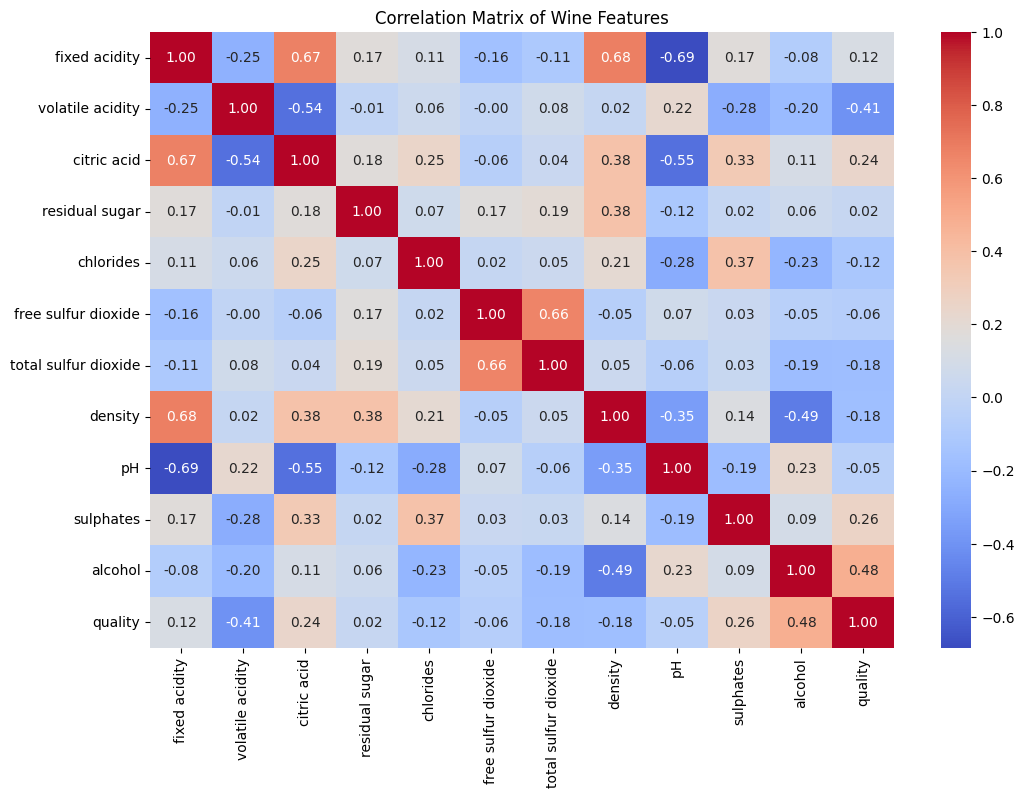

In [19]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix of Wine Features')
plt.show()

In [20]:
quality_correlation = correlation_matrix['quality'].sort_values(
    ascending=False
)

print("Correlation with Wine Quality:")
print(quality_correlation)

Correlation with Wine Quality:
quality                 1.000000
alcohol                 0.484866
sulphates               0.257710
citric acid             0.240821
fixed acidity           0.121970
residual sugar          0.022002
pH                     -0.052453
free sulfur dioxide    -0.063260
chlorides              -0.124085
density                -0.175208
total sulfur dioxide   -0.183339
volatile acidity       -0.407394
Name: quality, dtype: float64


## 6. Feature and Target Separation

In [21]:
X = df.drop('quality', axis=1)
y = df['quality']

print("Input features (X):")
print(X.columns.tolist())

print("\nTarget variable (y):")
print(y.name)

Input features (X):
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']

Target variable (y):
quality


In [22]:
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (1143, 11)
Shape of y: (1143,)


## 7. Train-Test Split

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nTesting data:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

Training data:
X_train: (914, 11)
y_train: (914,)

Testing data:
X_test: (229, 11)
y_test: (229,)


## 8. Feature Scaling

In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully!")

print("Scaled training data shape:", X_train_scaled.shape)
print("Scaled testing data shape:", X_test_scaled.shape)

Feature scaling completed successfully!
Scaled training data shape: (914, 11)
Scaled testing data shape: (229, 11)


## 9. Model Training
### 9.1 Linear Regression

In [25]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(X_train_scaled, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [26]:
y_pred_linear = linear_model.predict(X_test_scaled)

print("First 10 predictions:")
print(y_pred_linear[:10])

print("\nFirst 10 actual values:")
print(y_test.values[:10])

First 10 predictions:
[6.95385746 5.02640844 5.39890453 5.51600321 5.71611259 5.75715057
 5.40849803 6.37696803 6.23461386 5.06181701]

First 10 actual values:
[6 5 5 5 5 6 6 6 6 4]


In [27]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred_linear)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_linear))
r2 = r2_score(y_test, y_pred_linear)

n = X_test.shape[0]
p = X_test.shape[1]

adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))

print("Linear Regression Performance")
print("--------------------------------")
print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)
print("Adjusted R²:", adjusted_r2)

Linear Regression Performance
--------------------------------
MAE: 0.48314105009962494
RMSE: 0.6284580014003414
R²: 0.38783268260022674
Adjusted R²: 0.356801159598395


## 10. Ridge Regression

In [28]:
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train_scaled, y_train)

y_pred_ridge = ridge_model.predict(X_test_scaled)

print("Ridge Regression model trained successfully!")

Ridge Regression model trained successfully!


In [29]:
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_ridge = r2_score(y_test, y_pred_ridge)

n = X_test.shape[0]
p = X_test.shape[1]

adjusted_r2_ridge = 1 - ((1 - r2_ridge) * (n - 1) / (n - p - 1))

print("Ridge Regression Performance")
print("--------------------------------")
print("MAE:", mae_ridge)
print("RMSE:", rmse_ridge)
print("R²:", r2_ridge)
print("Adjusted R²:", adjusted_r2_ridge)

Ridge Regression Performance
--------------------------------
MAE: 0.48308821386293915
RMSE: 0.6283725595709655
R²: 0.3879991253532227
Adjusted R²: 0.3569760395416349


## 11. Lasso Regression

In [30]:
from sklearn.linear_model import Lasso

lasso_model = Lasso(alpha=0.01)

lasso_model.fit(X_train_scaled, y_train)

y_pred_lasso = lasso_model.predict(X_test_scaled)

print("Lasso Regression model trained successfully!")

Lasso Regression model trained successfully!


In [31]:
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
r2_lasso = r2_score(y_test, y_pred_lasso)

adjusted_r2_lasso = 1 - ((1 - r2_lasso) * (n - 1) / (n - p - 1))

print("Lasso Regression Performance")
print("--------------------------------")
print("MAE:", mae_lasso)
print("RMSE:", rmse_lasso)
print("R²:", r2_lasso)
print("Adjusted R²:", adjusted_r2_lasso)

Lasso Regression Performance
--------------------------------
MAE: 0.48087015575878284
RMSE: 0.6261771144897216
R²: 0.392268144075
Adjusted R²: 0.3614614601341014


## 12. Decision Tree Regression

In [32]:
from sklearn.tree import DecisionTreeRegressor

tree_model = DecisionTreeRegressor(
    random_state=42,
    max_depth=5
)

tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


In [33]:
mae_tree = mean_absolute_error(y_test, y_pred_tree)
rmse_tree = np.sqrt(mean_squared_error(y_test, y_pred_tree))
r2_tree = r2_score(y_test, y_pred_tree)

adjusted_r2_tree = 1 - ((1 - r2_tree) * (n - 1) / (n - p - 1))

print("Decision Tree Performance")
print("--------------------------------")
print("MAE:", mae_tree)
print("RMSE:", rmse_tree)
print("R²:", r2_tree)
print("Adjusted R²:", adjusted_r2_tree)

Decision Tree Performance
--------------------------------
MAE: 0.48645517081862555
RMSE: 0.6555846152526106
R²: 0.3338452539721033
Adjusted R²: 0.3000770410398136


## 13. Random Forest Regression

In [34]:
from sklearn.ensemble import RandomForestRegressor

random_forest_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    max_depth=10
)

random_forest_model.fit(X_train, y_train)

y_pred_rf = random_forest_model.predict(X_test)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [35]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

adjusted_r2_rf = 1 - ((1 - r2_rf) * (n - 1) / (n - p - 1))

print("Random Forest Performance")
print("--------------------------------")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R²:", r2_rf)
print("Adjusted R²:", adjusted_r2_rf)

Random Forest Performance
--------------------------------
MAE: 0.4342928109009878
RMSE: 0.6016269325537987
R²: 0.43898798928156835
Adjusted R²: 0.41054959242487366


## 14. Gradient Boosting Regression

In [36]:
from sklearn.ensemble import GradientBoostingRegressor

gradient_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gradient_model.fit(X_train, y_train)

y_pred_gradient = gradient_model.predict(X_test)

print("Gradient Boosting model trained successfully!")

Gradient Boosting model trained successfully!


In [37]:
mae_gradient = mean_absolute_error(y_test, y_pred_gradient)
rmse_gradient = np.sqrt(mean_squared_error(y_test, y_pred_gradient))
r2_gradient = r2_score(y_test, y_pred_gradient)

adjusted_r2_gradient = 1 - ((1 - r2_gradient) * (n - 1) / (n - p - 1))

print("Gradient Boosting Performance")
print("--------------------------------")
print("MAE:", mae_gradient)
print("RMSE:", rmse_gradient)
print("R²:", r2_gradient)
print("Adjusted R²:", adjusted_r2_gradient)

Gradient Boosting Performance
--------------------------------
MAE: 0.46064775933575747
RMSE: 0.6081651304703178
R²: 0.4267281037988532
Adjusted R²: 0.39766823809280427


## 15. Classification Model Training

### 15.1 Logistic Regression

In [38]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

logistic_model.fit(X_train_scaled, y_train)

y_pred_logistic = logistic_model.predict(X_test_scaled)

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


### 15.2 Random Forest Classifier

In [39]:
from sklearn.ensemble import RandomForestClassifier

rf_classifier = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_classifier.fit(X_train, y_train)

y_pred_rf_classifier = rf_classifier.predict(X_test)

print("Random Forest Classifier trained successfully!")

Random Forest Classifier trained successfully!


### 15.3 Support Vector Machine

In [40]:
from sklearn.svm import SVC

svm_model = SVC(
    kernel='rbf',
    probability=True,
    random_state=42
)

svm_model.fit(X_train_scaled, y_train)

y_pred_svm = svm_model.predict(X_test_scaled)

print("Support Vector Machine trained successfully!")

Support Vector Machine trained successfully!


### 15.4 K-Nearest Neighbors

In [41]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train_scaled, y_train)

y_pred_knn = knn_model.predict(X_test_scaled)

print("K-Nearest Neighbors trained successfully!")

K-Nearest Neighbors trained successfully!


## 16. Model Evaluation

In [42]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Calculate metrics for all models

models = {
    "Logistic Regression": y_pred_logistic,
    "Random Forest": y_pred_rf_classifier,
    "Support Vector Machine": y_pred_svm,
    "K-Nearest Neighbors": y_pred_knn
}

results = []

for model_name, predictions in models.items():
    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(y_test, predictions, average='weighted', zero_division=0)
    recall = recall_score(y_test, predictions, average='weighted', zero_division=0)
    f1 = f1_score(y_test, predictions, average='weighted', zero_division=0)

    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    })

results_df = pd.DataFrame(results)

print("Model Evaluation Results")
display(results_df)

Model Evaluation Results


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.624454,0.587715,0.624454,0.603652
1,Random Forest,0.716157,0.680045,0.716157,0.693633
2,Support Vector Machine,0.668122,0.639710,0.668122,0.642022
3,K-Nearest Neighbors,0.576419,0.553219,0.576419,0.563248


In [43]:
best_model_name = results_df.loc[
    results_df["F1-Score"].idxmax(), "Model"
]

print("Best-performing model:", best_model_name)

Best-performing model: Random Forest


## 17. Model Comparison Visualization

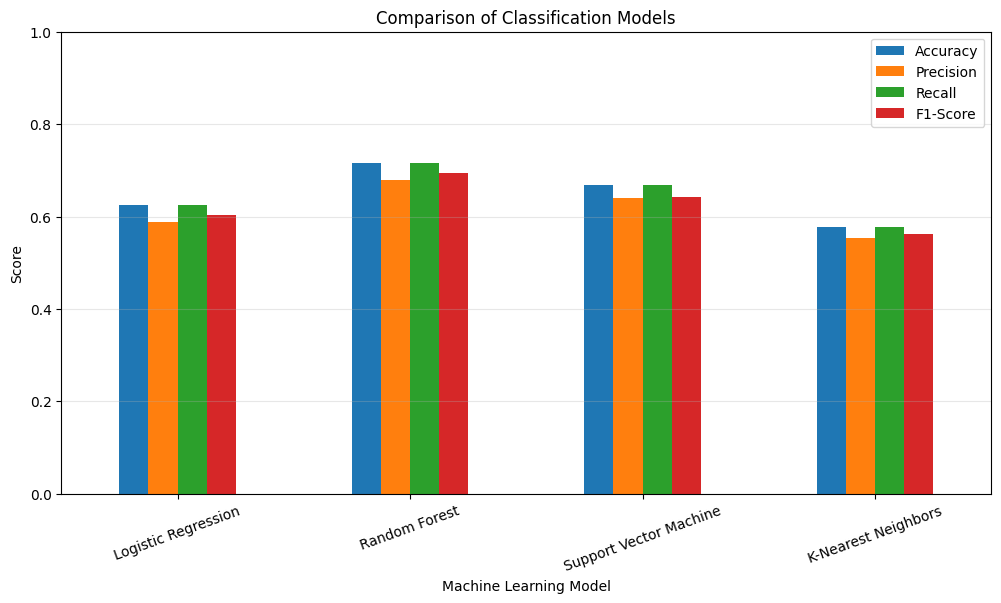

In [44]:
import matplotlib.pyplot as plt

results_plot = results_df.set_index("Model")

results_plot[["Accuracy", "Precision", "Recall", "F1-Score"]].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Comparison of Classification Models")
plt.ylabel("Score")
plt.xlabel("Machine Learning Model")
plt.xticks(rotation=20)
plt.ylim(0, 1)
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()

## 18. Confusion Matrix - Best Model

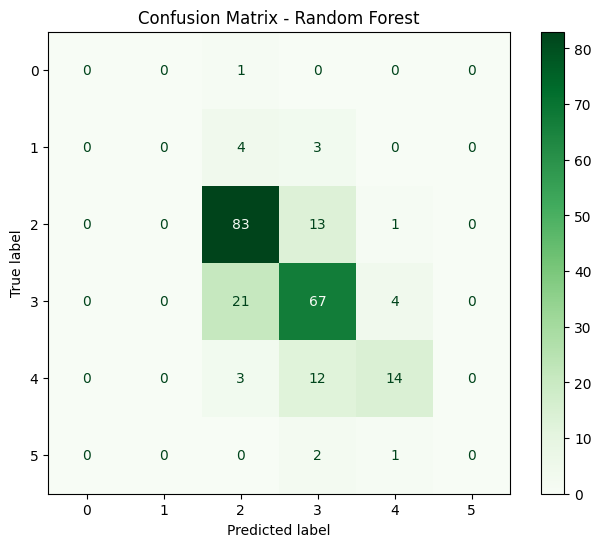

In [45]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Confusion matrix for the best model
cm = confusion_matrix(y_test, y_pred_rf_classifier)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap="Greens")

plt.title("Confusion Matrix - Random Forest")
plt.show()

## 19. Detailed Classification Report

In [46]:
from sklearn.metrics import classification_report

print("Random Forest Classification Report")
print("=" * 45)

print(
    classification_report(
        y_test,
        y_pred_rf_classifier,
        zero_division=0
    )
)

Random Forest Classification Report
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         7
           5       0.74      0.86      0.79        97
           6       0.69      0.73      0.71        92
           7       0.70      0.48      0.57        29
           8       0.00      0.00      0.00         3

    accuracy                           0.72       229
   macro avg       0.36      0.34      0.35       229
weighted avg       0.68      0.72      0.69       229



## 20. Feature Importance Analysis

In [47]:
# Get feature importance from Random Forest

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_classifier.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("Feature Importance:")
display(feature_importance)

Feature Importance:


,Feature,Importance
10,alcohol,0.146472
9,sulphates,0.116319
1,volatile acidity,0.108427
6,total sulfur dioxide,0.098369
7,density,0.087165
8,pH,0.079382
4,chlorides,0.078858
0,fixed acidity,0.077430
2,citric acid,0.076842
3,residual sugar,0.065683


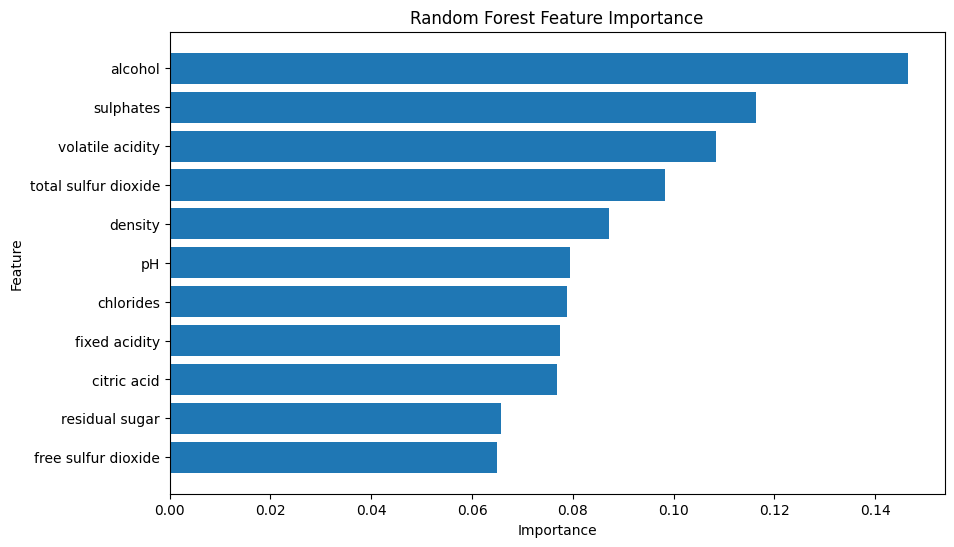

In [48]:
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.show()

## 21. Random Forest Hyperparameter Tuning

In [49]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Create a Random Forest model
rf_tuning = RandomForestClassifier(
    random_state=42
)

# Parameters to test
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# Grid Search
grid_search = GridSearchCV(
    estimator=rf_tuning,
    param_grid=param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1
)

# Train
grid_search.fit(X_train, y_train)

print("Hyperparameter tuning completed!")
print("\nBest Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation F1-Score:")
print(grid_search.best_score_)

Hyperparameter tuning completed!

Best Parameters:
{'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

Best Cross-Validation F1-Score:
0.6359547052456733


In [50]:
# Get the best Random Forest model
best_rf_model = grid_search.best_estimator_

# Make predictions on test data
y_pred_best_rf = best_rf_model.predict(X_test)

print("Optimized Random Forest trained successfully!")

Optimized Random Forest trained successfully!


## 22. Optimized Random Forest Performance

In [51]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy_best = accuracy_score(y_test, y_pred_best_rf)
precision_best = precision_score(
    y_test, y_pred_best_rf,
    average='weighted',
    zero_division=0
)
recall_best = recall_score(
    y_test, y_pred_best_rf,
    average='weighted',
    zero_division=0
)
f1_best = f1_score(
    y_test, y_pred_best_rf,
    average='weighted',
    zero_division=0
)

print("Optimized Random Forest Performance")
print("=" * 45)
print("Accuracy :", accuracy_best)
print("Precision:", precision_best)
print("Recall   :", recall_best)
print("F1-Score :", f1_best)

Optimized Random Forest Performance
Accuracy : 0.7161572052401747
Precision: 0.682174663328421
Recall   : 0.7161572052401747
F1-Score : 0.6939095602645294


In [52]:
print("Random Forest Before Tuning")
print("=" * 35)
print("Accuracy :", accuracy_score(y_test, y_pred_rf_classifier))
print("Precision:", precision_score(y_test, y_pred_rf_classifier, average='weighted', zero_division=0))
print("Recall   :", recall_score(y_test, y_pred_rf_classifier, average='weighted', zero_division=0))
print("F1-Score :", f1_score(y_test, y_pred_rf_classifier, average='weighted', zero_division=0))

print("\nRandom Forest After Tuning")
print("=" * 35)
print("Accuracy :", accuracy_best)
print("Precision:", precision_best)
print("Recall   :", recall_best)
print("F1-Score :", f1_best)

Random Forest Before Tuning
Accuracy : 0.7161572052401747
Precision: 0.6800450669170564
Recall   : 0.7161572052401747
F1-Score : 0.6936332052397325

Random Forest After Tuning
Accuracy : 0.7161572052401747
Precision: 0.682174663328421
Recall   : 0.7161572052401747
F1-Score : 0.6939095602645294


## 23. Confusion Matrix - Optimized Random Forest

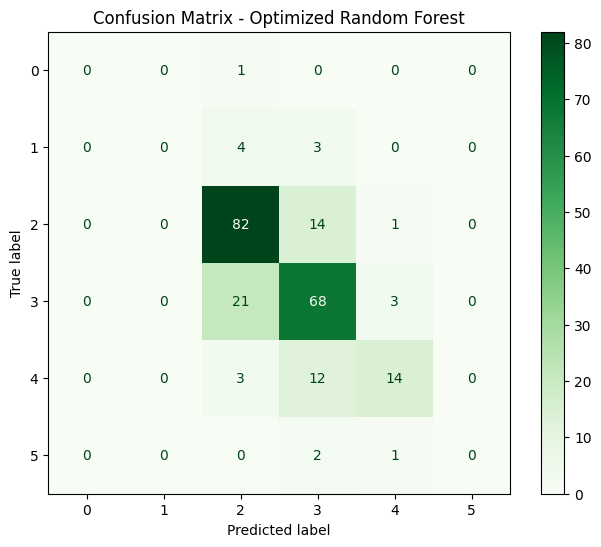

In [53]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_best = confusion_matrix(y_test, y_pred_best_rf)

fig, ax = plt.subplots(figsize=(8, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_best
)

disp.plot(ax=ax, cmap="Greens")

plt.title("Confusion Matrix - Optimized Random Forest")
plt.show()

In [54]:
print("Classification Report - Optimized Random Forest")
print("=" * 55)

print(
    classification_report(
        y_test,
        y_pred_best_rf,
        zero_division=0
    )
)

Classification Report - Optimized Random Forest
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         7
           5       0.74      0.85      0.79        97
           6       0.69      0.74      0.71        92
           7       0.74      0.48      0.58        29
           8       0.00      0.00      0.00         3

    accuracy                           0.72       229
   macro avg       0.36      0.34      0.35       229
weighted avg       0.68      0.72      0.69       229



## 24. Wine Quality Prediction System

In [56]:
def predict_wine_quality(
    fixed_acidity,
    volatile_acidity,
    citric_acid,
    residual_sugar,
    chlorides,
    free_sulfur_dioxide,
    total_sulfur_dioxide,
    density,
    pH,
    sulphates,
    alcohol
):

    # Create input data
    input_data = pd.DataFrame([[
        fixed_acidity,
        volatile_acidity,
        citric_acid,
        residual_sugar,
        chlorides,
        free_sulfur_dioxide,
        total_sulfur_dioxide,
        density,
        pH,
        sulphates,
        alcohol
    ]], columns=X.columns)

    # Predict wine quality
    prediction = best_rf_model.predict(input_data)[0]

    # Get prediction probabilities
    probabilities = best_rf_model.predict_proba(input_data)[0]

    # Confidence of predicted class
    confidence = max(probabilities) * 100

    # Convert numerical quality into category
    if prediction <= 4:
        category = "Poor"
    elif prediction == 5:
        category = "Average"
    elif prediction == 6:
        category = "Good"
    elif prediction == 7:
        category = "Very Good"
    else:
        category = "Excellent"

    print("🍷 WINE QUALITY PREDICTION")
    print("=" * 35)
    print("Predicted Quality Score:", prediction)
    print("Quality Category:", category)
    print("Prediction Confidence: {:.2f}%".format(confidence))

In [57]:
predict_wine_quality(
    fixed_acidity=7.4,
    volatile_acidity=0.70,
    citric_acid=0.00,
    residual_sugar=1.9,
    chlorides=0.076,
    free_sulfur_dioxide=11,
    total_sulfur_dioxide=34,
    density=0.9978,
    pH=3.51,
    sulphates=0.56,
    alcohol=9.4
)

🍷 WINE QUALITY PREDICTION
Predicted Quality Score: 5
Quality Category: Average
Prediction Confidence: 97.94%


In [58]:
predict_wine_quality(
    fixed_acidity=8.5,
    volatile_acidity=0.45,
    citric_acid=0.50,
    residual_sugar=2.0,
    chlorides=0.075,
    free_sulfur_dioxide=15,
    total_sulfur_dioxide=40,
    density=0.9950,
    pH=3.30,
    sulphates=0.75,
    alcohol=11.5
)

🍷 WINE QUALITY PREDICTION
Predicted Quality Score: 6
Quality Category: Good
Prediction Confidence: 65.94%


## 25. Interactive Wine Quality Predictor

In [59]:
import ipywidgets as widgets
from IPython.display import display

# Create input boxes
fixed_acidity_input = widgets.FloatText(value=7.4, description='Fixed Acidity:')
volatile_acidity_input = widgets.FloatText(value=0.70, description='Volatile Acidity:')
citric_acid_input = widgets.FloatText(value=0.00, description='Citric Acid:')
residual_sugar_input = widgets.FloatText(value=1.9, description='Residual Sugar:')
chlorides_input = widgets.FloatText(value=0.076, description='Chlorides:')
free_sulfur_input = widgets.FloatText(value=11, description='Free SO2:')
total_sulfur_input = widgets.FloatText(value=34, description='Total SO2:')
density_input = widgets.FloatText(value=0.9978, description='Density:')
ph_input = widgets.FloatText(value=3.51, description='pH:')
sulphates_input = widgets.FloatText(value=0.56, description='Sulphates:')
alcohol_input = widgets.FloatText(value=9.4, description='Alcohol:')

predict_button = widgets.Button(
    description='Predict Wine Quality',
    button_style='success'
)

output = widgets.Output()

def on_predict_clicked(b):
    with output:
        output.clear_output()

        predict_wine_quality(
            fixed_acidity_input.value,
            volatile_acidity_input.value,
            citric_acid_input.value,
            residual_sugar_input.value,
            chlorides_input.value,
            free_sulfur_input.value,
            total_sulfur_input.value,
            density_input.value,
            ph_input.value,
            sulphates_input.value,
            alcohol_input.value
        )

predict_button.on_click(on_predict_clicked)

display(
    fixed_acidity_input,
    volatile_acidity_input,
    citric_acid_input,
    residual_sugar_input,
    chlorides_input,
    free_sulfur_input,
    total_sulfur_input,
    density_input,
    ph_input,
    sulphates_input,
    alcohol_input,
    predict_button,
    output
)

FloatText(value=7.4, description='Fixed Acidity:')

FloatText(value=0.7, description='Volatile Acidity:')

FloatText(value=0.0, description='Citric Acid:')

FloatText(value=1.9, description='Residual Sugar:')

FloatText(value=0.076, description='Chlorides:')

...

FloatText(value=3.51, description='pH:')

FloatText(value=0.56, description='Sulphates:')

FloatText(value=9.4, description='Alcohol:')

Button(button_style='success', description='Predict Wine Quality', style=ButtonStyle())

Output()

# 18. Project Conclusion

The Wine Quality Prediction System was developed using machine learning techniques to predict wine quality based on its physicochemical properties.

Different machine learning models were trained and evaluated using appropriate performance metrics. Among the tested models, the optimized Random Forest model provided the best classification performance.

The system successfully accepts wine characteristics such as acidity, sugar, sulphates, alcohol, pH, density and sulfur dioxide levels and generates a predicted wine quality score along with a quality category and prediction confidence.

For the sample input, the system predicted:

- Predicted Quality Score: 5
- Quality Category: Average
- Prediction Confidence: 97.94%

The project demonstrates how machine learning can be applied to analyze wine characteristics and build an interactive wine quality prediction system.